# 08 - Deep learning model 1: MLP with embeddings (PyTorch)
Needs notebook 05 output and `pip install torch`. Early stopping and the threshold use the validation set only.

In [1]:
import sys, os
from pathlib import Path
# works whether Jupyter starts in the project root or inside notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))      # lets us import data_utils.py from the root
print("Project root:", ROOT)

Project root: c:\Users\aru12\OneDrive\Desktop\capstone project


## 1. Imports, data and category vocabularies (train only)

In [2]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [3]:
import copy, numpy as np, pandas as pd, torch, torch.nn as nn
from sklearn.metrics import roc_auc_score
from data_utils import *

torch.manual_seed(SEED); np.random.seed(SEED)
dev = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", dev)
(Xtr, ytr), (Xva, yva), (Xte, yte) = load_splits()

# vocabularies come from TRAIN only; unseen categories map to index 0
vocab = {c: {v: i + 1 for i, v in enumerate(sorted(Xtr[c].unique()))} for c in FEATURES}
def enc(X):
    return torch.tensor(np.stack([X[c].map(vocab[c]).fillna(0).astype(int).to_numpy()
                                  for c in FEATURES], 1), dtype=torch.long).to(dev)
Ctr, Cva, Cte = enc(Xtr), enc(Xva), enc(Xte)
Ytr = torch.tensor(ytr, dtype=torch.float32).to(dev)

device: cpu


## 2. Model, loss (class-weighted) and optimizer

In [4]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(len(vocab[c]) + 1, min(32, len(vocab[c]) // 2 + 2))
                                   for c in FEATURES])
        d = sum(e.embedding_dim for e in self.embs)
        self.mlp = nn.Sequential(nn.Linear(d, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
                                 nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
                                 nn.Linear(64, 1))
    def forward(self, c):
        return self.mlp(torch.cat([e(c[:, i]) for i, e in enumerate(self.embs)], 1)).squeeze(1)

net = Net().to(dev)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor((ytr == 0).sum() / (ytr == 1).sum(),
                                                        dtype=torch.float32).to(dev))
opt = torch.optim.AdamW(net.parameters(), lr=2e-3, weight_decay=1e-4)
print(net)

Net(
  (embs): ModuleList(
    (0): Embedding(32, 17)
    (1): Embedding(139, 32)
    (2): Embedding(276, 32)
  )
  (mlp): Sequential(
    (0): Linear(in_features=81, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 3. Train with early stopping on validation AUC

In [5]:
def predict(C):
    net.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(C), 8192):
            out.append(torch.sigmoid(net(C[i:i + 8192])))
    return torch.cat(out).cpu().numpy()

best_auc, best_state, bad, BS = 0, None, 0, 2048
for ep in range(30):
    net.train(); perm = torch.randperm(len(Ctr), device=dev)
    for i in range(0, len(perm), BS):
        idx = perm[i:i + BS]
        opt.zero_grad(); loss_fn(net(Ctr[idx]), Ytr[idx]).backward(); opt.step()
    auc = roc_auc_score(yva, predict(Cva))            # early stopping uses VALIDATION only
    print(f"epoch {ep+1:02d}  val_auc={auc:.4f}")
    if auc > best_auc: best_auc, best_state, bad = auc, copy.deepcopy(net.state_dict()), 0
    else:
        bad += 1
        if bad >= 4: break

epoch 01  val_auc=0.9149
epoch 02  val_auc=0.9163
epoch 03  val_auc=0.9175
epoch 04  val_auc=0.9175
epoch 05  val_auc=0.9179
epoch 06  val_auc=0.9183
epoch 07  val_auc=0.9180
epoch 08  val_auc=0.9184
epoch 09  val_auc=0.9182
epoch 10  val_auc=0.9182
epoch 11  val_auc=0.9186
epoch 12  val_auc=0.9182
epoch 13  val_auc=0.9184
epoch 14  val_auc=0.9186
epoch 15  val_auc=0.9185


In [6]:
## 4. Restore best epoch, pick threshold on validation, evaluate on test
from sklearn.metrics import (average_precision_score, f1_score, precision_score, recall_score,
                             accuracy_score, balanced_accuracy_score)

net.load_state_dict(best_state)
print(f"Best val AUC: {best_auc:.4f}")

pva, pte = predict(Cva), predict(Cte)
yva_, yte_ = np.asarray(yva), np.asarray(yte)

# threshold chosen on validation only (balanced accuracy, same as the other rows in the results file)
ths = np.linspace(0.05, 0.95, 91)
best_t = ths[int(np.argmax([balanced_accuracy_score(yva_, pva >= t) for t in ths]))]
print(f"Threshold (from val): {best_t:.2f}")

yh = (pte >= best_t).astype(int)
row = {
    "Model": "MLP (embeddings)",
    "Features": "Primary Type + Location Description + Beat",
    "Train/Val/Test": "2023-Jun24 / Jul-Dec24 / 2025",
    "Test_rows": len(Xte),
    "Threshold": round(float(best_t), 2),
    "Accuracy": round(accuracy_score(yte_, yh), 4),
    "Balanced_Accuracy": round(balanced_accuracy_score(yte_, yh), 4),
    "Precision": round(precision_score(yte_, yh, zero_division=0), 4),
    "Recall": round(recall_score(yte_, yh), 4),
    "F1": round(f1_score(yte_, yh), 4),
    "ROC_AUC": round(roc_auc_score(yte_, pte), 4),
}
pd.DataFrame([row]).T

Best val AUC: 0.9186
Threshold (from val): 0.55


,0
Model,MLP (embeddings)
Features,Primary Type + Location Description + Beat
Train/Val/Test,2023-Jun24 / Jul-Dec24 / 2025
Test_rows,236927
Threshold,0.55
Accuracy,0.8269
Balanced_Accuracy,0.8345
Precision,0.5287
Recall,0.8469
F1,0.651


In [7]:
## 5. Save model and add/replace the row in outputs/leakfree_results.csv
torch.save({"state_dict": best_state, "vocab": vocab, "features": FEATURES, "threshold": float(best_t)},
           ROOT / "models" / "mlp_embeddings.pt")

(ROOT / "outputs").mkdir(exist_ok=True)
res_path = ROOT / "outputs" / "leakfree_results.csv"

if res_path.exists():
    res = pd.read_csv(res_path)
    res = res[res["Model"] != row["Model"]]            # re-running replaces the old MLP row
    res = pd.concat([res, pd.DataFrame([row])[res.columns]], ignore_index=True)
else:
    res = pd.DataFrame([row])

res.to_csv(res_path, index=False)
print("Saved ->", res_path)
res[res["Model"] == "MLP (embeddings)"]                # show only this model's row

Saved -> c:\Users\aru12\OneDrive\Desktop\capstone project\outputs\leakfree_results.csv


,Model,Features,Train/Val/Test,Test_rows,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
6,MLP (embeddings),Primary Type + Location Description + Beat,2023-Jun24 / Jul-Dec24 / 2025,236927.0,0.55,0.8269,0.8345,0.5287,0.8469,0.651,0.9136


,Model,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
Rank,,,,,,,,
1,MLP (embeddings),0.55,0.8269,0.8345,0.5287,0.8469,0.6510,0.9136
2,XGBoost,0.52,0.8312,0.8311,0.5371,0.8309,0.6524,0.9125
3,LightGBM,0.69,0.8669,0.8092,0.6335,0.7160,0.6723,0.9114
4,HistGradientBoosting,0.55,0.8313,0.8306,0.5373,0.8294,0.6521,0.9114
5,RandomForest,0.51,0.8305,0.8299,0.5359,0.8290,0.6510,0.9103
6,LogisticRegression,0.53,0.8271,0.8276,0.5299,0.8285,0.6463,0.9094


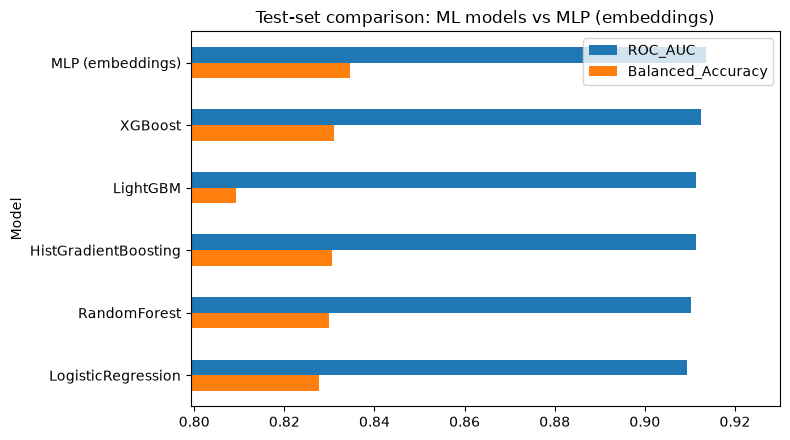

In [8]:
## 6. Comparison table: ML models + MLP (embeddings)
import matplotlib.pyplot as plt

res = pd.read_csv(ROOT / "outputs" / "leakfree_results.csv")

# keep ML models + this notebook's DL model only (FT-Transformer excluded)
res = res[res["Model"] != "FT-Transformer (DL)"]

cols = ["Model", "Threshold", "Accuracy", "Balanced_Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
cmp = (res[cols].sort_values("ROC_AUC", ascending=False)
                .reset_index(drop=True))
cmp.index += 1                                          # rank starts at 1
cmp.index.name = "Rank"

display(cmp.style
        .format({c: "{:.4f}" for c in cols[2:]} | {"Threshold": "{:.2f}"})
        .highlight_max(subset=cols[2:], color="#c6efce"))   # best value in each metric column

# bar chart of ROC_AUC and Balanced_Accuracy
ax = cmp.set_index("Model")[["ROC_AUC", "Balanced_Accuracy"]].plot.barh(figsize=(8, 4.5))
ax.invert_yaxis()
ax.set_xlim(cmp[["ROC_AUC", "Balanced_Accuracy"]].min().min() - 0.01, 0.93)
ax.set_title("Test-set comparison: ML models vs MLP (embeddings)")
plt.tight_layout(); plt.show()

Chicago MLP Confusion Matrix — 2025 Test Set
Threshold: 0.55
                         Prediction outcome  Count
        True Domestic predicted as Domestic  38261
    True Domestic predicted as Non-Domestic   6916
    True Non-Domestic predicted as Domestic  34101
True Non-Domestic predicted as Non-Domestic 157649


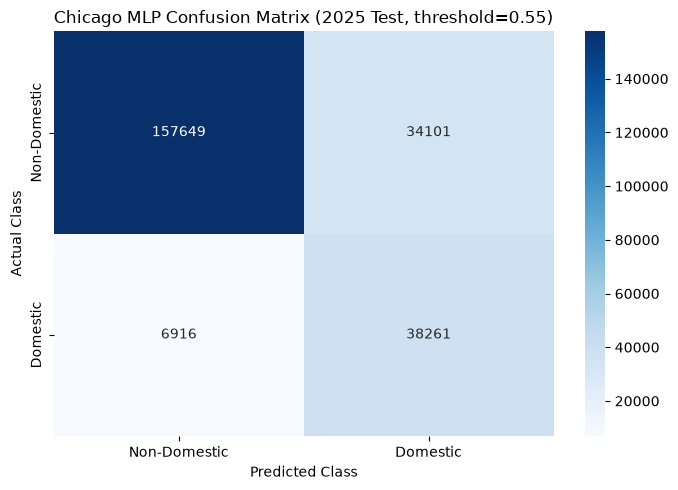

In [10]:

from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use the exact predictions and threshold from your MLP evaluation
y_true = yte_
y_pred = (pte >= best_t).astype(int)

# Confusion matrix: labels 0 = Non-Domestic, 1 = Domestic
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

# Print the four exact counts
confusion_table = pd.DataFrame({
    "Prediction outcome": [
        "True Domestic predicted as Domestic",
        "True Domestic predicted as Non-Domestic",
        "True Non-Domestic predicted as Domestic",
        "True Non-Domestic predicted as Non-Domestic"
    ],
    "Count": [tp, fn, fp, tn]
})

print("Chicago MLP Confusion Matrix — 2025 Test Set")
print(f"Threshold: {best_t:.2f}")
print(confusion_table.to_string(index=False))

# Plot confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Domestic", "Domestic"],
    yticklabels=["Non-Domestic", "Domestic"]
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title(f"Chicago MLP Confusion Matrix (2025 Test, threshold={best_t:.2f})")
plt.tight_layout()
plt.show()


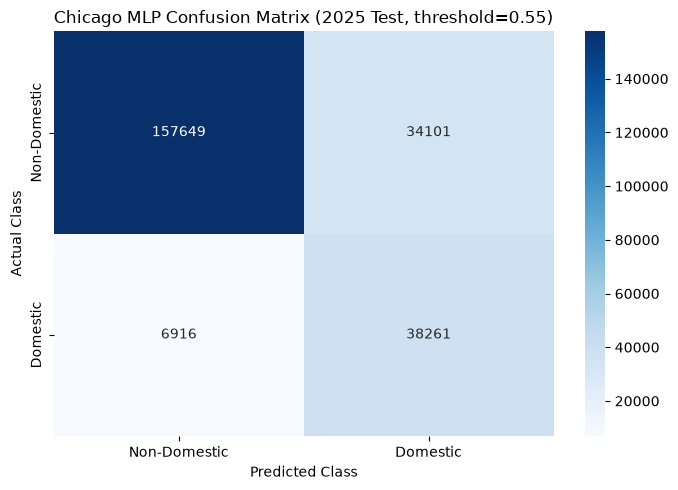

Image exists: True
Image saved at: C:\Users\aru12\OneDrive\Desktop\capstone project\outputs\mlp_confusion_matrix_2025.png
CSV saved at: C:\Users\aru12\OneDrive\Desktop\capstone project\outputs\mlp_confusion_matrix_2025.csv


In [12]:

# Save the confusion matrix image and CSV in outputs
out_dir = ROOT / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Domestic", "Domestic"],
    yticklabels=["Non-Domestic", "Domestic"],
    ax=ax
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")
ax.set_title(f"Chicago MLP Confusion Matrix (2025 Test, threshold={best_t:.2f})")

fig.tight_layout()

# Save BEFORE displaying
img_path = out_dir / "mlp_confusion_matrix_2025.png"
fig.savefig(img_path, dpi=300, bbox_inches="tight")

# Save exact counts
csv_path = out_dir / "mlp_confusion_matrix_2025.csv"
confusion_table.to_csv(csv_path, index=False)

plt.show()
plt.close(fig)

print("Image exists:", img_path.exists())
print("Image saved at:", img_path.resolve())
print("CSV saved at:", csv_path.resolve())
